# Kernel SVM for All Failure Labels

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

In [11]:
DATA_PATH = Path("data/ai4i2020.csv")
TARGET_COLUMNS = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
DROP_COLUMNS = ["UID", "Product ID"]
KERNELS = ["linear", "rbf", "poly", "sigmoid"]
RANDOM_STATE = 42
TEST_SIZE = 0.2

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=DROP_COLUMNS + TARGET_COLUMNS)
y = df[TARGET_COLUMNS]

cat_features = X.select_dtypes(include=["object"]).columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y["Machine failure"])

print(f"Dataset: {df.shape}, Train: {X_train.shape}, Test: {X_test.shape}")


Dataset: (10000, 14), Train: (8000, 6), Test: (2000, 6)


In [12]:
def create_model(kernel):
    preprocessor = ColumnTransformer([("num", StandardScaler(), num_features), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)])
    clf = OneVsRestClassifier(SVC(kernel=kernel, class_weight="balanced", random_state=RANDOM_STATE))
    return Pipeline([("preprocessor", preprocessor), ("classifier", clf)])


In [13]:
kernel_metrics = []
kernel_predictions = {}

for kernel in KERNELS:
    model = create_model(kernel)
    model.fit(X_train, y_train)
    pred_df = pd.DataFrame(model.predict(X_test), columns=TARGET_COLUMNS, index=y_test.index)
    kernel_predictions[kernel] = pred_df

    for target in TARGET_COLUMNS:
        kernel_metrics.append({
            "kernel": kernel, "target": target,
            "precision": precision_score(y_test[target], pred_df[target], zero_division=0),
            "recall": recall_score(y_test[target], pred_df[target], zero_division=0),
            "f1": f1_score(y_test[target], pred_df[target], zero_division=0)
        })

metrics_df = pd.DataFrame(kernel_metrics)
metrics_df


,kernel,target,precision,recall,f1
0,linear,Machine failure,0.150396,0.838235,0.255034
1,linear,TWF,0.043011,0.800000,0.081633
2,linear,HDF,0.322222,1.000000,0.487395
3,linear,PWF,0.419355,1.000000,0.590909
4,linear,OSF,0.551724,1.000000,0.711111
5,linear,RNF,0.004016,0.750000,0.007989
6,rbf,Machine failure,0.278539,0.897059,0.425087
7,rbf,TWF,0.056604,0.600000,0.103448
8,rbf,HDF,0.383562,0.965517,0.549020
9,rbf,PWF,0.481481,1.000000,0.650000


In [14]:
kernel_summary = metrics_df.groupby("kernel")[["precision", "recall", "f1"]].mean().sort_values("f1", ascending=False)
kernel_summary


,precision,recall,f1
kernel,,,
poly,0.322604,0.846214,0.433470
rbf,0.273192,0.785429,0.390678
linear,0.248454,0.898039,0.355678
sigmoid,0.030704,0.686338,0.057618


In [15]:
best_kernel = kernel_summary.index[0]
best_predictions = kernel_predictions[best_kernel]

print(f"Best kernel: {best_kernel}")
best_predictions.head()


Best kernel: poly


,Machine failure,TWF,HDF,PWF,OSF,RNF
2997,1,0,0,1,0,1
4871,0,0,0,0,0,0
3858,0,1,0,0,0,1
951,0,0,1,0,0,0
6463,1,0,0,0,0,0


In [16]:
metrics_df[metrics_df["kernel"] == best_kernel].drop("kernel", axis=1).reset_index(drop=True)


,target,precision,recall,f1
0,Machine failure,0.269565,0.911765,0.416107
1,TWF,0.061404,0.700000,0.112903
2,HDF,0.388889,0.965517,0.554455
3,PWF,0.541667,1.000000,0.702703
4,OSF,0.666667,1.000000,0.800000
5,RNF,0.007435,0.500000,0.014652


In [17]:
print(f"Classification reports for {best_kernel}:\n")
for target in TARGET_COLUMNS:
    y_true = y_test[target]
    y_pred = kernel_predictions[best_kernel][target]
    print(f"{target}:\n{classification_report(y_true, y_pred, zero_division=0)}")


Classification reports for poly:

Machine failure:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1932
           1       0.27      0.91      0.42        68

    accuracy                           0.91      2000
   macro avg       0.63      0.91      0.68      2000
weighted avg       0.97      0.91      0.93      2000

TWF:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1990
           1       0.06      0.70      0.11        10

    accuracy                           0.94      2000
   macro avg       0.53      0.82      0.54      2000
weighted avg       0.99      0.94      0.97      2000

HDF:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1971
           1       0.39      0.97      0.55        29

    accuracy                           0.98      2000
   macro avg       0.69      0.97      0.77      2000
weighted avg 

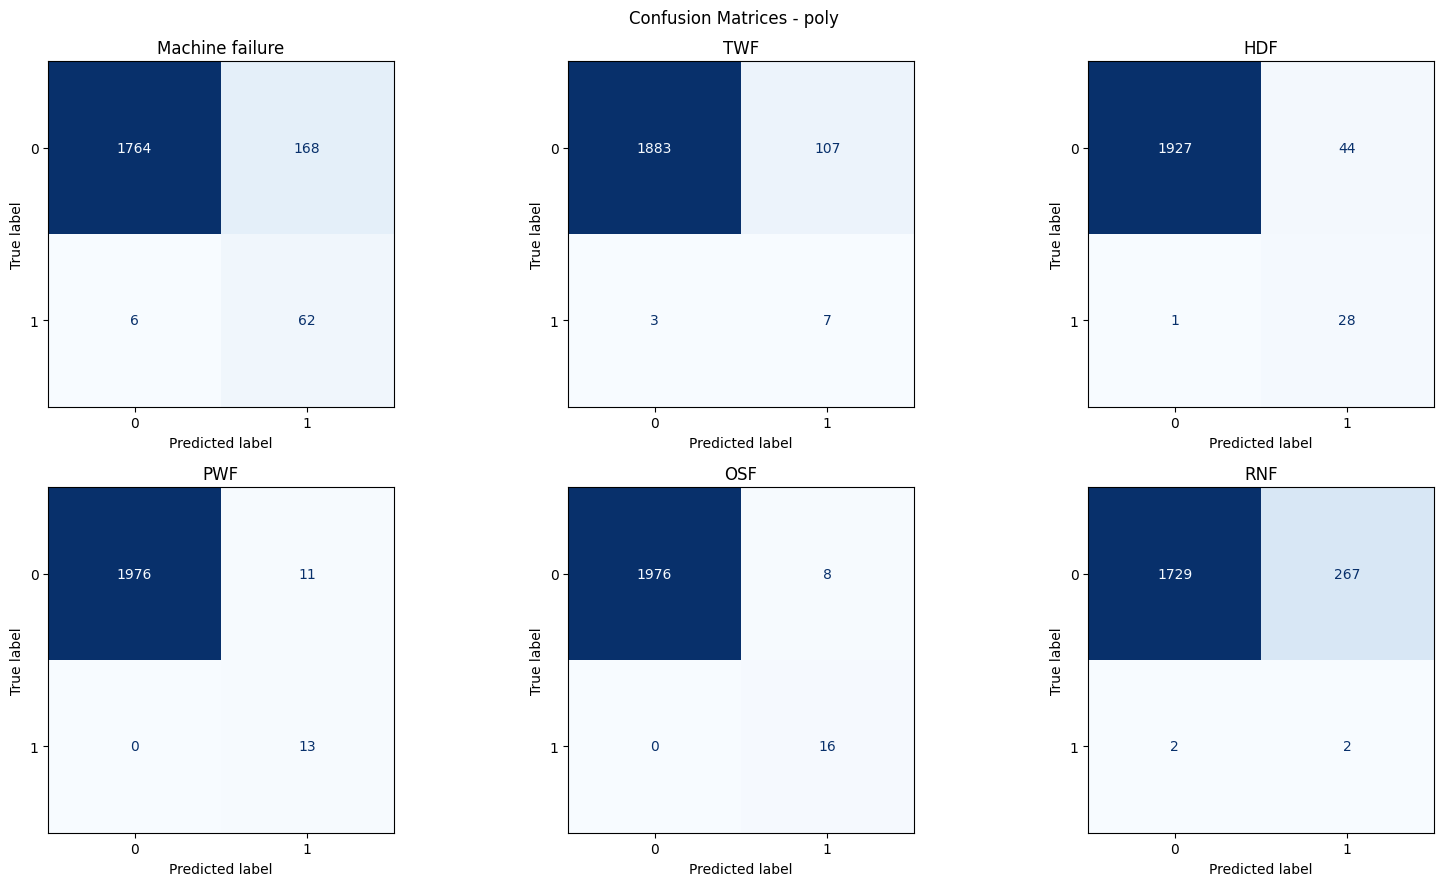

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, target in enumerate(TARGET_COLUMNS):
    y_true = y_test[target]
    y_pred = kernel_predictions[best_kernel][target]
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=[0, 1], cmap="Blues", colorbar=False, ax=axes.flat[i])
    axes.flat[i].set_title(target)
plt.suptitle(f"Confusion Matrices - {best_kernel}")
plt.tight_layout()
plt.show()
